In [1]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import average_precision_score

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score, 
    precision_recall_curve,
    classification_report
)
pd.set_option("display.max_rows", None)
from statsmodels.tools.sm_exceptions import PerfectSeparationError

TARGET = "fraud"
LABEL = "fraud"

%matplotlib inline

BASELINE = [
    # 거래 강도
    "log_abs_amount",
    "amount_income_ratio",
    "amount_limit_ratio",

    # 에러
    "has_error",

    # 고객 맥락 최소
    "credit_limit",
    "current_age",

    # 카드 특성
    "is_credit",
    "has_chip",
]

In [2]:
df = pd.read_parquet("data")

In [3]:
df.columns

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'merchant_id', 'mcc',
       'fraud', 'has_error', 'err_bad_card_number', 'err_bad_expiration',
       'err_bad_cvv', 'err_insufficient_balance', 'err_technical_glitch',
       'weekday', 'is_refund', 'log_abs_amount', 'current_age',
       'per_capita_income', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards', 'has_chip', 'num_cards_issued', 'credit_limit',
       'year_pin_last_changed', 'expires_year', 'expires_month',
       'months_to_expire', 'is_credit', 'is_prepaid', 'male', 'cb_Visa',
       'cb_Mastercard', 'cb_Amex', 'cb_Discover', 'months_from_account',
       'years_since_pin_change', 'years_to_retirement', 'income_ratio_region',
       'log_yearly_income', 'log_income_ratio_region', 'abs_amount',
       'amount_income_ratio', 'amount_limit_ratio', 'log_amount_income_ratio',
       'log_amount_limit_ratio', 'month_sin', 'is_risky_month',
       'is_risky_wd_hour', 'is_risky_hour', 'hour_sin', 'ho

In [33]:
err_type_cols = [
    'err_bad_cvv',
    'err_bad_card_number',
    'err_bad_expiration',
    'err_insufficient_balance',
    'err_technical_glitch'
]

any_err = df[err_type_cols].any(axis=1).astype(int)

mismatch = ((any_err == 1) & (df['has_error'] == 0)).sum()
extra = ((df['has_error'] == 1) & (any_err == 0)).sum()

print(f"세부 에러 있는데 has_error=0: {mismatch}")
print(f"has_error=1인데 세부 에러 전부 0: {extra}")

세부 에러 있는데 has_error=0: 0
has_error=1인데 세부 에러 전부 0: 0


In [34]:
base_rate = df['fraud'].mean()

def lift(col):
    rate = df.groupby(col)['fraud'].mean()
    return rate[1] / base_rate

print("has_error lift:", lift('has_error'))
for c in err_type_cols:
    print(c, lift(c))

has_error lift: 1.9354858804378097
err_bad_cvv 3.999564082827192
err_bad_card_number 1.3714666010022694
err_bad_expiration 1.3093342194103732
err_insufficient_balance 1.755937035433854
err_technical_glitch 1.1892076087861336


In [4]:
base_rate = df["fraud"].mean()

err_cols = [c for c in df.columns if c.startswith("err") or "error" in c]

rows = []

for col in err_cols:
    grp = df.groupby(col)["fraud"].mean()
    
    if 1 in grp.index:
        fraud_rate = grp.loc[1]
        lift = fraud_rate / base_rate
        rows.append({
            "feature": col,
            "fraud_rate_when_1": fraud_rate,
            "lift": lift,
            "support_rate": df[col].mean()
        })

pd.DataFrame(rows).sort_values("lift", ascending=False)

,feature,fraud_rate_when_1,lift,support_rate
3,err_bad_cvv,0.050718,3.999564,0.004057
0,has_error,0.024544,1.935486,0.022856
4,err_insufficient_balance,0.022267,1.755937,0.007758
1,err_bad_card_number,0.017391,1.371467,0.005134
2,err_bad_expiration,0.016603,1.309334,0.004092
5,err_technical_glitch,0.015080,1.189208,0.002059


- err_*는 독립 위험 신호인지, 아니면 금액/시간대/특정 카드,고객 행동의 대리변수인지 확인해야 한다.

- has_error는 포괄 플래그이므로, 세부 err_*와 중복/대체 관계(다중공선성) 정리까지 가야 한다.

- err_bad_cvv는 lift가 매우 크지만 support가 낮아 과적합/불안정 가능성이 있으므로 신뢰구간/안정성 체크가 필요

In [5]:
ERR_COLS = [
    "has_error",
    "err_bad_cvv",
    "err_insufficient_balance",
    "err_bad_card_number",
    "err_bad_expiration",
    "err_technical_glitch",
]

base_rate = float(df[TARGET].mean())
base_rate

0.012680807782789972

In [6]:
err_ratio = (
    df.groupby("fraud")[ERR_COLS]
      .mean()
)

err_ratio

,has_error,err_bad_cvv,err_insufficient_balance,err_bad_card_number,err_bad_expiration,err_technical_glitch
fraud,,,,,,
0,0.022581,0.003900,0.007683,0.005110,0.004075,0.002054
1,0.044237,0.016225,0.013623,0.007041,0.005357,0.002449


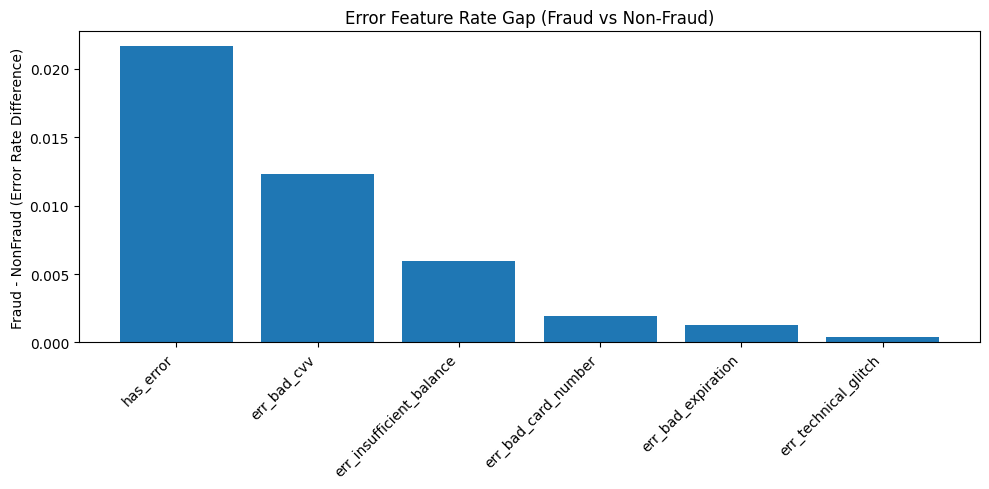

In [7]:
err_ratio = df.groupby("fraud")[ERR_COLS].mean()

nonfraud = err_ratio.loc[0] if 0 in err_ratio.index else pd.Series(0, index=ERR_COLS)
fraud    = err_ratio.loc[1] if 1 in err_ratio.index else pd.Series(0, index=ERR_COLS)

diff = (fraud - nonfraud).sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(np.arange(len(diff)), diff.values)
plt.xticks(np.arange(len(diff)), diff.index, rotation=45, ha="right")
plt.ylabel("Fraud - NonFraud (Error Rate Difference)")
plt.title("Error Feature Rate Gap (Fraud vs Non-Fraud)")
plt.tight_layout()
plt.show()

In [8]:
def err_summary_table(df, cols, label="fraud"):
    out = []
    base = float(df[label].mean())
    n_all = len(df)

    for c in cols:
        g = df.groupby(c)[label].agg(["count", "sum", "mean"]).rename(
            columns={"count":"tx_cnt", "sum":"fraud_cnt", "mean":"fraud_rate"}
        )
        # 1이 없는 경우 대비
        if 0 not in g.index:
            g.loc[0] = [0, 0, np.nan]
        if 1 not in g.index:
            g.loc[1] = [0, 0, np.nan]
        g = g.sort_index()

        tx1 = int(g.loc[1, "tx_cnt"])
        fr1 = int(g.loc[1, "fraud_cnt"])
        r1  = float(g.loc[1, "fraud_rate"]) if tx1 > 0 else np.nan

        tx0 = int(g.loc[0, "tx_cnt"])
        fr0 = int(g.loc[0, "fraud_cnt"])
        r0  = float(g.loc[0, "fraud_rate"]) if tx0 > 0 else np.nan

        support = tx1 / n_all if n_all > 0 else np.nan
        lift1 = r1 / base if base > 0 else np.nan

        # Wilson CI (fraud_rate_when_1) for stability

        def wilson_ci(k, n, z=1.96):
            if n == 0:
                return (np.nan, np.nan)
            p = k / n
            denom = 1 + z**2 / n
            center = (p + z**2/(2*n)) / denom
            half = (z * np.sqrt((p*(1-p) + z**2/(4*n)) / n)) / denom
            return (center - half, center + half)

        lo1, hi1 = wilson_ci(fr1, tx1)

        out.append({
            "feature": c,
            "support_rate": support,
            "tx_cnt_1": tx1,
            "fraud_cnt_1": fr1,
            "fraud_rate_1": r1,
            "fraud_rate_1_ci_low": lo1,
            "fraud_rate_1_ci_high": hi1,
            "tx_cnt_0": tx0,
            "fraud_cnt_0": fr0,
            "fraud_rate_0": r0,
            "base_rate": base,
            "lift_1": lift1,
        })
    return pd.DataFrame(out).sort_values("lift_1", ascending=False)

err_tbl = err_summary_table(df, ERR_COLS, label=LABEL)
err_tbl

,feature,support_rate,tx_cnt_1,fraud_cnt_1,fraud_rate_1,fraud_rate_1_ci_low,fraud_rate_1_ci_high,tx_cnt_0,fraud_cnt_0,fraud_rate_0,base_rate,lift_1
1,err_bad_cvv,0.004057,2090,106,0.050718,0.042107,0.060977,513098,6427,0.012526,0.012681,3.999564
0,has_error,0.022856,11775,289,0.024544,0.021900,0.027497,503413,6244,0.012403,0.012681,1.935486
2,err_insufficient_balance,0.007758,3997,89,0.022267,0.018130,0.027321,511191,6444,0.012606,0.012681,1.755937
3,err_bad_card_number,0.005134,2645,46,0.017391,0.013064,0.023119,512543,6487,0.012656,0.012681,1.371467
4,err_bad_expiration,0.004092,2108,35,0.016603,0.011962,0.023003,513080,6498,0.012665,0.012681,1.309334
5,err_technical_glitch,0.002059,1061,16,0.015080,0.009303,0.024356,514127,6517,0.012676,0.012681,1.189208


In [36]:
df.groupby('err_technical_glitch')['fraud'].agg(['mean','count'])

,mean,count
err_technical_glitch,,
0,0.012676,514127
1,0.015080,1061


> err_technical_glitch는 사기 위험 신호라기보다는 시스템 품질 지표

In [40]:
df = df.sort_values(['card_id','date'])

df['card_fraud_cum_prev'] = (
    df.groupby('card_id')['fraud']
      .cumsum()
      .shift(1)
      .fillna(0)
)

# fraud 이전 상태의 거래들
df_pre = df[df['card_fraud_cum_prev'] == 0].copy()

In [41]:
df_pre['error_count'] = df_pre[err_type_cols].sum(axis=1)

base_rate = df_pre['fraud'].mean()

summary = (
    df_pre.groupby('error_count')['fraud']
      .agg(['mean','count'])
      .assign(lift=lambda x: x['mean']/base_rate)
)

summary

,mean,count,lift
error_count,,,
0,0.002485,408396,0.987185
1,0.003847,9359,1.527872
2,0.009709,103,3.856353
3,0.000000,1,0.000000


In [42]:
# error_count만 단일 피처로 score 사용
from sklearn.metrics import roc_auc_score, average_precision_score

score = df_pre['error_count']
y = df_pre['fraud']

print("ROC AUC:", roc_auc_score(y, score))
print("PR AUC:", average_precision_score(y, score))

ROC AUC: 0.5062845613065201
PR AUC: 0.0025719902207383964


> 단조 증가 구조지만 분포 불균형 때문 ranking power lack 

> error_count는 conditional risk는 높지만\
> global ranking power는 약함

-> 단독으로 쓰기보단 이후 Interaction 또는 flga로 사용해야 함

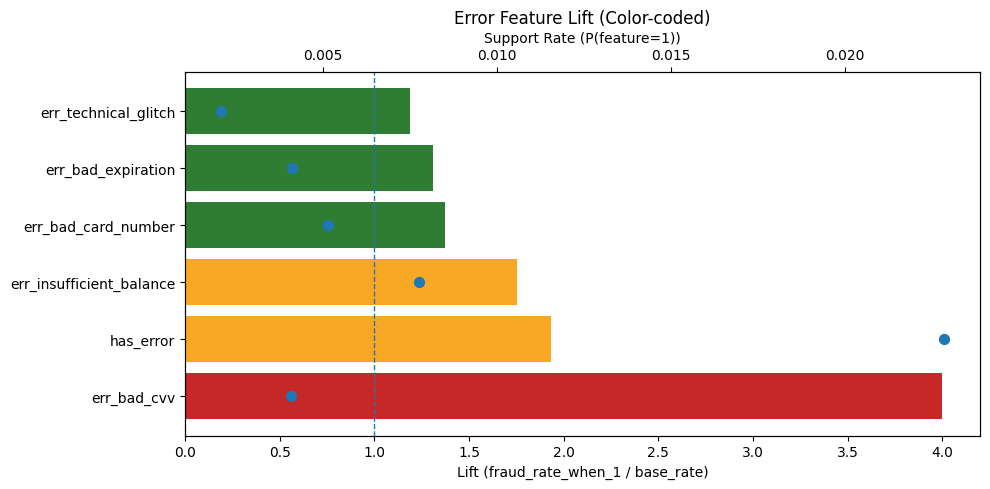

In [9]:
def lift_color(l):
    if np.isnan(l): return "lightgray"
    if l >= 3.0: return "#C62828"   # strong
    if l >= 2.0: return "#EF6C00"   # high
    if l >= 1.5: return "#F9A825"   # mid
    if l >= 1.0: return "#2E7D32"   # weak+
    return "#546E7A"               # below baseline

plot_df = err_tbl.copy()
plot_df["color"] = plot_df["lift_1"].apply(lift_color)

fig, ax1 = plt.subplots(figsize=(10, 5))

y = np.arange(len(plot_df))
ax1.barh(y, plot_df["lift_1"], color=plot_df["color"])
ax1.axvline(1.0, linestyle="--", linewidth=1)

ax1.set_yticks(y)
ax1.set_yticklabels(plot_df["feature"])
ax1.set_xlabel("Lift (fraud_rate_when_1 / base_rate)")
ax1.set_title("Error Feature Lift (Color-coded)")

ax2 = ax1.twiny()
ax2.scatter(plot_df["support_rate"], y, s=50, marker="o")
ax2.set_xlabel("Support Rate (P(feature=1))")

plt.tight_layout()
plt.show()

*support_rate = tx_cnt_1 / 전체 거래 수

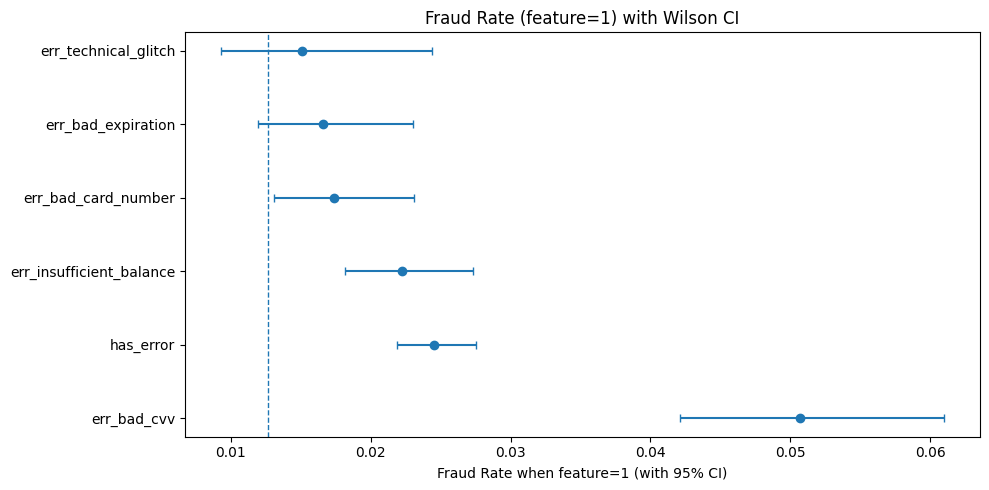

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

y = np.arange(len(plot_df))
rate = plot_df["fraud_rate_1"]
lo = plot_df["fraud_rate_1_ci_low"]
hi = plot_df["fraud_rate_1_ci_high"]

ax.errorbar(rate, y, xerr=[rate-lo, hi-rate], fmt="o", capsize=3)
ax.axvline(base_rate, linestyle="--", linewidth=1)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"])
ax.set_xlabel("Fraud Rate when feature=1 (with 95% CI)")
ax.set_title("Fraud Rate (feature=1) with Wilson CI")

plt.tight_layout()
plt.show()

## *err_bad_cvv -> 매우 강한 신호* => **WHY**

In [11]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

TARGET = "err_bad_cvv"
LABEL = "fraud"

EXCLUDE = {TARGET, LABEL}

# ID/식별자류 자동 제외(필요하면 추가)
ID_HINTS = ("_id", "id")
EXCLUDE_IDS = [c for c in df.columns if c.lower().endswith(ID_HINTS) or c.lower() in ["id"]]
EXCLUDE |= set(EXCLUDE_IDS)

# numeric 후보
num_candidates = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c])
    and not pd.api.types.is_timedelta64_dtype(df[c])
    and c not in EXCLUDE
]

# binary(0/1) vs continuous 분리
BIN_COLS = []
CONT_COLS = []
for c in num_candidates:
    vals = set(df[c].dropna().unique())
    if vals.issubset({0, 1}):
        BIN_COLS.append(c)
    else:
        CONT_COLS.append(c)

BIN_COLS[:10], CONT_COLS[:10]

(['has_error',
  'err_bad_card_number',
  'err_bad_expiration',
  'err_insufficient_balance',
  'err_technical_glitch',
  'is_refund',
  'has_chip',
  'is_credit',
  'male',
  'cb_Visa'],
 ['amount',
  'weekday',
  'log_abs_amount',
  'current_age',
  'per_capita_income',
  'yearly_income',
  'total_debt',
  'credit_score',
  'num_credit_cards',
  'num_cards_issued'])

In [12]:
from scipy.stats import mannwhitneyu

g0 = df[df[TARGET] == 0]
g1 = df[df[TARGET] == 1]

rows = []
for col in tqdm(CONT_COLS):
    x0 = g0[col].dropna()
    x1 = g1[col].dropna()
    if len(x0) < 50 or len(x1) < 50:
        continue

    stat, p = mannwhitneyu(x0, x1, alternative="two-sided")

    mean0, mean1 = x0.mean(), x1.mean()
    std0, std1 = x0.std(), x1.std()
    pooled = np.sqrt((std0**2 + std1**2) / 2)
    d = (mean1 - mean0) / pooled if pooled > 0 else np.nan

    rows.append({
        "feature": col,
        "mean_cvv0": float(mean0),
        "mean_cvv1": float(mean1),
        "delta_mean": float(mean1 - mean0),
        "p_value": float(p),
        "cohens_d": float(d) if pd.notnull(d) else np.nan,
    })

cont_diff = (
    pd.DataFrame(rows)
      .sort_values("cohens_d", key=lambda s: s.abs(), ascending=False)
      .reset_index(drop=True)
)

cont_diff.head(30)

  0%|          | 0/29 [00:00<?, ?it/s]

,feature,mean_cvv0,mean_cvv1,delta_mean,p_value,cohens_d
0,amount,5.728864e+01,6.625870e+01,8.970055e+00,0.019986,0.081803
1,abs_amount,6.062506e+01,6.884434e+01,8.219276e+00,0.032189,0.076142
2,log_yearly_income,1.067369e+01,1.064651e+01,-2.717590e-02,0.008052,-0.054118
3,log_abs_amount,3.646827e+00,3.691405e+00,4.457760e-02,0.032189,0.046397
4,total_debt,5.882998e+04,5.682905e+04,-2.000930e+03,0.019535,-0.039941
5,log_amount_limit_ratio,3.554002e-02,4.069743e-02,5.157407e-03,0.003217,0.039235
6,credit_score,7.092073e+02,7.116933e+02,2.486037e+00,0.289730,0.035449
7,num_credit_cards,3.805651e+00,3.859330e+00,5.367898e-02,0.131212,0.032512
8,credit_limit,1.619492e+04,1.580457e+04,-3.903574e+02,0.061044,-0.031444
9,log_income_ratio_region,1.107300e+00,1.136709e+00,2.940941e-02,0.148148,0.027556


> CVV 오류 집단은 금액/소득/시간 구조에서 뚜렷한 이상 패턴을 보이지 않는다.

### 수치형 피처: Mann–Whitney + Cohen’s d

In [13]:
from scipy.stats import chi2_contingency

BIN_COLS = [
    c for c in df.columns
    if set(df[c].dropna().unique()).issubset({0,1})
    and c not in ["err_bad_cvv"]
]

rows = []
for col in tqdm(BIN_COLS):
    ct = pd.crosstab(df[TARGET], df[col])

    # 2x2 아닌 경우 제외
    if ct.shape != (2, 2):
        continue
    ct = ct.reindex(index=[0,1], columns=[0,1], fill_value=0)

    # 확률(비율)
    p1_cvv1 = ct.loc[1,1] / ct.loc[1].sum() if ct.loc[1].sum() > 0 else np.nan
    p1_cvv0 = ct.loc[0,1] / ct.loc[0].sum() if ct.loc[0].sum() > 0 else np.nan
    risk_diff = p1_cvv1 - p1_cvv0

    # OR(0 방지용 continuity correction)
    a = ct.loc[1,1] + 0.5
    b = ct.loc[1,0] + 0.5
    c_ = ct.loc[0,1] + 0.5
    d = ct.loc[0,0] + 0.5
    OR = (a*d) / (b*c_)

    chi2, p, _, _ = chi2_contingency(ct)

    rows.append({
        "feature": col,
        "P(feature=1 | cvv=1)": float(p1_cvv1),
        "P(feature=1 | cvv=0)": float(p1_cvv0),
        "risk_diff": float(risk_diff),
        "odds_ratio": float(OR),
        "p_value": float(p),
        "ct_00": int(ct.loc[0,0]),
        "ct_01": int(ct.loc[0,1]),
        "ct_10": int(ct.loc[1,0]),
        "ct_11": int(ct.loc[1,1]),
    })

bin_diff = (
    pd.DataFrame(rows)
      .sort_values("risk_diff", key=lambda s: s.abs(), ascending=False)
      .reset_index(drop=True)
)

bin_diff.head(30)

  0%|          | 0/18 [00:00<?, ?it/s]

,feature,P(feature=1 | cvv=1),P(feature=1 | cvv=0),risk_diff,odds_ratio,p_value,ct_00,ct_01,ct_10,ct_11
0,has_error,1.000000,0.018876,0.981124,217311.635280,0.000000e+00,503413,9685,0,2090
1,fraud,0.050718,0.012526,0.038192,4.230414,5.151808e-54,506671,6427,1984,106
2,cb_Visa,0.385167,0.365390,0.019777,1.088285,6.417555e-02,325617,187481,1285,805
3,cb_Mastercard,0.521053,0.539328,-0.018275,0.929214,9.879268e-02,236370,276728,1001,1089
4,has_chip,0.903828,0.913252,-0.009425,0.890723,1.366322e-01,44510,468588,201,1889
5,is_credit,0.310048,0.303034,0.007014,1.033985,5.012904e-01,357612,155486,1442,648
6,is_prepaid,0.083254,0.076317,0.006937,1.102007,2.499255e-01,473940,39158,1916,174
7,is_risky_wd_hour,0.056459,0.060006,-0.003547,0.941076,5.252574e-01,482309,30789,1972,118
8,err_insufficient_balance,0.010526,0.007747,0.002779,1.393023,1.867390e-01,509123,3975,2068,22
9,cb_Discover,0.021053,0.023050,-0.001998,0.921570,5.930816e-01,501271,11827,2046,44


> has_error는 너무 당연한 정의상 포함 관계 있음 주의\
> CVV 오류는 다른 feature의 매개를 통해 fraud가 되는 게 아니다.

> err_bad_card_number -> drop 

| 조건                 | 판단  |
| ------------------ | --- |
| 단독 hazard 강함       | 아니오 |
| CVV와 상호보완          | 아니오 |
| error_count에 이미 포함 | 예   |
| has_error에도 포함     | 예   |


In [14]:
cont_sig = cont_diff[(cont_diff["cohens_d"].abs() >= 0.10)].head(30)
bin_sig  = bin_diff[(bin_diff["risk_diff"].abs() >= 0.01)].head(30)

display(cont_sig)
display(bin_sig)

,feature,mean_cvv0,mean_cvv1,delta_mean,p_value,cohens_d


,feature,P(feature=1 | cvv=1),P(feature=1 | cvv=0),risk_diff,odds_ratio,p_value,ct_00,ct_01,ct_10,ct_11
0,has_error,1.000000,0.018876,0.981124,217311.635280,0.000000e+00,503413,9685,0,2090
1,fraud,0.050718,0.012526,0.038192,4.230414,5.151808e-54,506671,6427,1984,106
2,cb_Visa,0.385167,0.365390,0.019777,1.088285,6.417555e-02,325617,187481,1285,805
3,cb_Mastercard,0.521053,0.539328,-0.018275,0.929214,9.879268e-02,236370,276728,1001,1089


> err_bad_cvv는 다른 피처들과 “강하게 구조적으로 다른 집단”이 아니다.\
> 그런데도 fraud OR ≈ 4가 나온다.

> 그럼 왜 OR = 4.2? 
- 그 자체로 이미 정상적인 소비 행동의 분포 밖에 있는 행위

In [15]:
# 카드별 CVV error 총 횟수
card_cvv_cnt = (
    df.groupby("card_id")["err_bad_cvv"]
      .sum()
      .reset_index()
      .rename(columns={"err_bad_cvv": "cvv_error_count"})
)

# 카드별 fraud 발생 여부
card_fraud_flag = (
    df.groupby("card_id")["fraud"]
      .max()
      .reset_index()
      .rename(columns={"fraud": "has_fraud"})
)

# merge
card_summary = card_cvv_cnt.merge(card_fraud_flag, on="card_id")

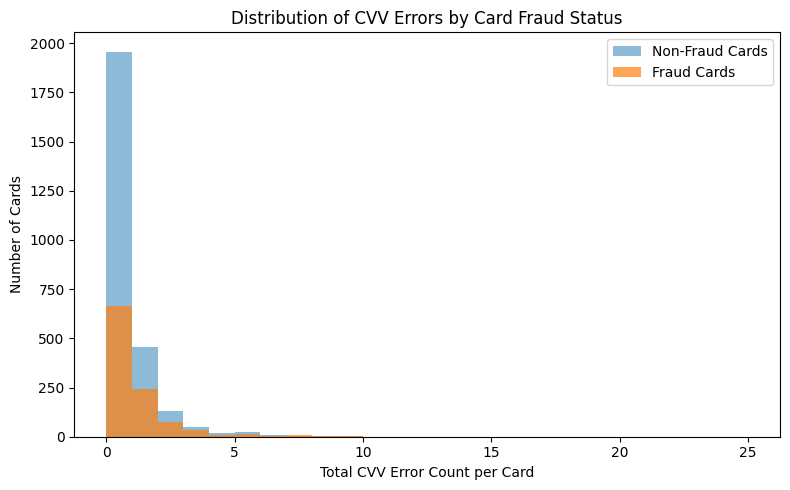

In [16]:
fraud_cards = card_summary[card_summary["has_fraud"] == 1]
nonfraud_cards = card_summary[card_summary["has_fraud"] == 0]

plt.figure(figsize=(8,5))


plt.hist(
    nonfraud_cards["cvv_error_count"],
    bins=range(0, nonfraud_cards["cvv_error_count"].max()+2),
    alpha=0.5,
    label="Non-Fraud Cards"
)

plt.hist(
    fraud_cards["cvv_error_count"],
    bins=range(0, fraud_cards["cvv_error_count"].max()+2),
    alpha=0.7,
    label="Fraud Cards"
)

plt.xlabel("Total CVV Error Count per Card")
plt.ylabel("Number of Cards")
plt.title("Distribution of CVV Errors by Card Fraud Status")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# 카드 수 대비 비율
fraud_dist = (
    fraud_cards["cvv_error_count"]
      .value_counts(normalize=True)
      .sort_index()
)

nonfraud_dist = (
    nonfraud_cards["cvv_error_count"]
      .value_counts(normalize=True)
      .sort_index()
)

dist_df = pd.concat(
    [fraud_dist, nonfraud_dist],
    axis=1
).fillna(0)

dist_df.columns = ["Fraud_Card_Ratio", "NonFraud_Card_Ratio"]

dist_df.head(20)

,Fraud_Card_Ratio,NonFraud_Card_Ratio
cvv_error_count,,
0,0.625000,0.734334
1,0.229323,0.171482
2,0.072368,0.048780
3,0.031955,0.017636
4,0.007519,0.007880
5,0.013158,0.008630
6,0.005639,0.004128
7,0.006579,0.001501
8,0.003759,0.001876


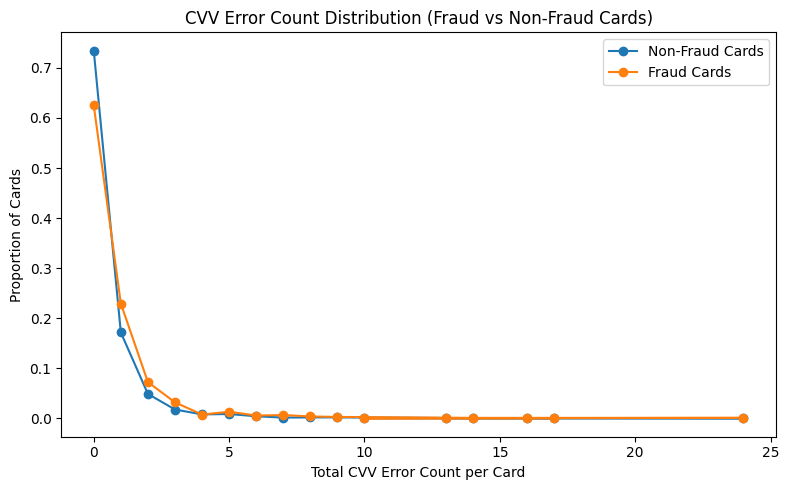

In [18]:
plt.figure(figsize=(8,5))
plt.plot(dist_df.index, dist_df["NonFraud_Card_Ratio"], marker="o", label="Non-Fraud Cards")
plt.plot(dist_df.index, dist_df["Fraud_Card_Ratio"], marker="o", label="Fraud Cards")

plt.xlabel("Total CVV Error Count per Card")
plt.ylabel("Proportion of Cards")
plt.title("CVV Error Count Distribution (Fraud vs Non-Fraud Cards)")
plt.legend()
plt.tight_layout()
plt.show()

> CVV error가 1회 이상이면 fraud 카드 비율이 더 높다.\
> “fraud 카드 대부분이 CVV error를 겪는다”는 건 아니다.

! 이건 error수만을 나타내지 fraud 이전 시기에서의 cvv error가 아니므로 이를 확인해봐야함 

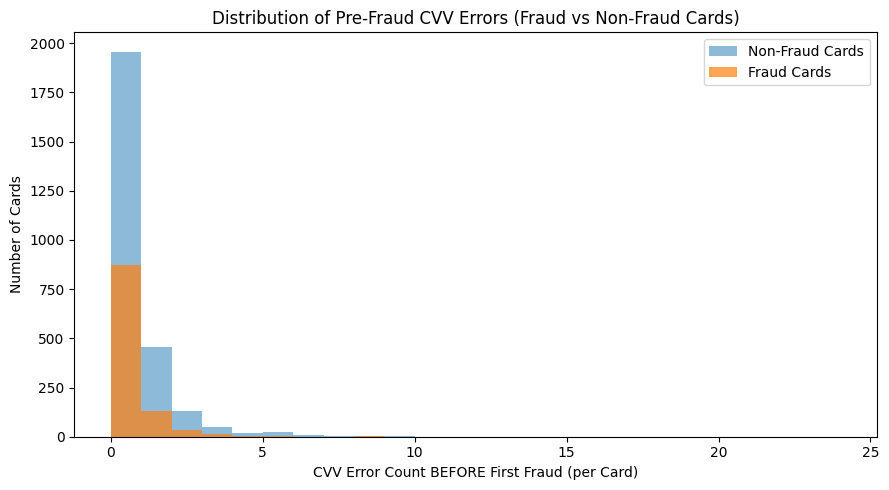

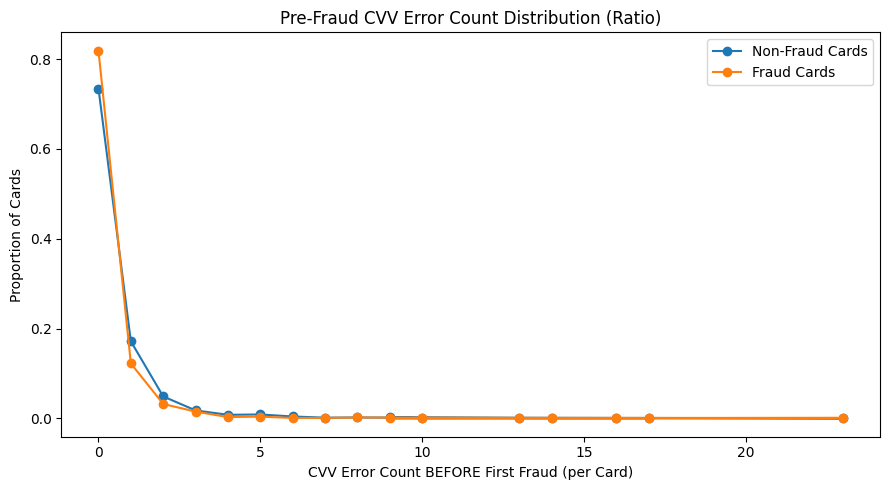

,Fraud_Card_Ratio,NonFraud_Card_Ratio
cvv_before_fraud,,
0,0.818609,0.734334
1,0.122180,0.171482
2,0.031955,0.048780
3,0.015038,0.017636
4,0.002820,0.007880
5,0.003759,0.008630
6,0.000940,0.004128
7,0.000940,0.001501
8,0.001880,0.001876


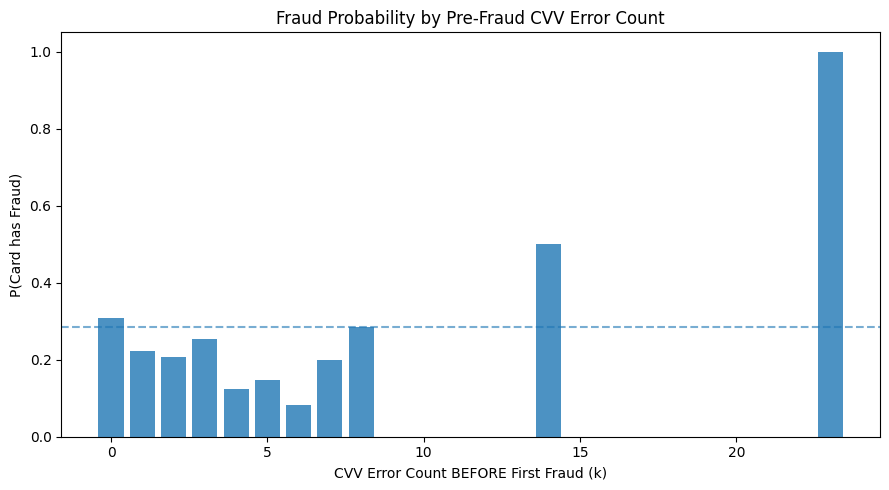

,cvv_before_fraud,card_cnt,fraud_rate,fraud_cnt,lift_vs_base
0,0,2828,0.307992,871,1.079418
1,1,587,0.221465,130,0.776168
2,2,164,0.207317,34,0.726584
3,3,63,0.253968,16,0.890082
4,4,24,0.125000,3,0.438087
5,5,27,0.148148,4,0.519215
6,6,12,0.083333,1,0.292058
7,7,5,0.200000,1,0.700940
8,8,7,0.285714,2,1.001343
9,9,5,0.000000,0,0.000000


In [19]:
# 시간순 정렬
df_sorted = df.sort_values(["card_id", "date"])

# fraud 발생 시점 표시
df_sorted["fraud_cum"] = df_sorted.groupby("card_id")["fraud"].cumsum()

# fraud 발생 이전 거래만 필터
pre_fraud_df = df_sorted[df_sorted["fraud_cum"] == 0]

# 카드별 fraud 발생 여부
card_has_fraud = df_sorted.groupby("card_id")["fraud"].max()

# fraud 이전 CVV error 누적 횟수
pre_cvv = (
    pre_fraud_df.groupby("card_id")["err_bad_cvv"]
    .sum()
)

card_pre_summary = pd.DataFrame({
    "cvv_before_fraud": pre_cvv,
    "has_fraud": card_has_fraud
}).fillna(0)

card_pre_summary = card_pre_summary.copy()
card_pre_summary["cvv_before_fraud"] = card_pre_summary["cvv_before_fraud"].astype(int)
card_pre_summary["has_fraud"] = card_pre_summary["has_fraud"].astype(int)

fraud_cards = card_pre_summary[card_pre_summary["has_fraud"] == 1]
nonfraud_cards = card_pre_summary[card_pre_summary["has_fraud"] == 0]


# 1) 분포(Count) 히스토그램: 겹쳐보기

max_k = int(card_pre_summary["cvv_before_fraud"].max())
bins = np.arange(0, max_k + 2)  # 0..max_k+1

plt.figure(figsize=(9,5))
plt.hist(nonfraud_cards["cvv_before_fraud"], bins=bins, alpha=0.5, label="Non-Fraud Cards")
plt.hist(fraud_cards["cvv_before_fraud"],    bins=bins, alpha=0.7, label="Fraud Cards")
plt.xlabel("CVV Error Count BEFORE First Fraud (per Card)")
plt.ylabel("Number of Cards")
plt.title("Distribution of Pre-Fraud CVV Errors (Fraud vs Non-Fraud Cards)")
plt.legend()
plt.tight_layout()
plt.show()


# 2) 분포(비율) 라인플롯: 카드 비중 비교

fraud_dist = fraud_cards["cvv_before_fraud"].value_counts(normalize=True).sort_index()
nonfraud_dist = nonfraud_cards["cvv_before_fraud"].value_counts(normalize=True).sort_index()

dist_df = pd.concat([fraud_dist, nonfraud_dist], axis=1).fillna(0)
dist_df.columns = ["Fraud_Card_Ratio", "NonFraud_Card_Ratio"]

plt.figure(figsize=(9,5))

plt.plot(dist_df.index, dist_df["NonFraud_Card_Ratio"], marker="o", label="Non-Fraud Cards")
plt.plot(dist_df.index, dist_df["Fraud_Card_Ratio"], marker="o", label="Fraud Cards")
plt.xlabel("CVV Error Count BEFORE First Fraud (per Card)")
plt.ylabel("Proportion of Cards")
plt.title("Pre-Fraud CVV Error Count Distribution (Ratio)")
plt.legend()
plt.tight_layout()
plt.show()

display(dist_df)


# 3) P(Fraud | cvv_before_fraud = k) : 조건부 사기확률

rate_df = (
    card_pre_summary
    .groupby("cvv_before_fraud")["has_fraud"]
    .agg(card_cnt="count", fraud_rate="mean", fraud_cnt="sum")
    .reset_index()
    .sort_values("cvv_before_fraud")
)

base_fraud_rate = float(card_pre_summary["has_fraud"].mean())
rate_df["lift_vs_base"] = rate_df["fraud_rate"] / base_fraud_rate if base_fraud_rate > 0 else np.nan

plt.figure(figsize=(9,5))
plt.bar(rate_df["cvv_before_fraud"], rate_df["fraud_rate"], alpha=0.8)
plt.axhline(base_fraud_rate, linestyle="--", alpha=0.6)
plt.xlabel("CVV Error Count BEFORE First Fraud (k)")
plt.ylabel("P(Card has Fraud)")
plt.title("Fraud Probability by Pre-Fraud CVV Error Count")
plt.tight_layout()
plt.show()

display(rate_df)

CVV error 0회 카드의 fraud_rate가 오히려 가장 높음

CVV 1~3회 구간은 fraud_rate가 오히려 낮아짐

8, 14, 23 같은 구간은 표본이 1~2개라 의미 없음

즉,

“fraud 이전에 CVV error를 많이 겪은 카드가 fraud로 이어진다”는 패턴은 보이지 않는다.

CVV error는

누적 위험 신호가 아니다

공격 전 반복 시도의 전조 신호가 아니다

hazard 상승 패턴이 없다

즉,

CVV error는 “사건 직전 행동 신호”이지 “장기 누적 위험 신호”는 아니다.

거래 단위 로지스틱에서는:

CVV error가 발생한 그 거래 자체가 매우 위험하다.

하지만 카드 단위 누적 분석에서는:

CVV error를 여러 번 겪은 카드가 fraud로 이어진다는 증거는 없다.

In [20]:
df.groupby("err_bad_cvv")["fraud"].mean()

err_bad_cvv
0    0.012526
1    0.050718
Name: fraud, dtype: float64

> CVV error는 “그 순간” 사기 가능성을 급증시키는 이벤트형 신호다.

> CVV는:\
> Stage1 real-time 모델에 매우 적합\
> Stage2 누적/행동 히스토리 피처로는 적합하지 않음\
> hazard feature로 쓰기에는 근거 부족

### 이진 피처: 카이제곱 + Odds Ratio

In [21]:
from scipy.stats import chi2_contingency

BIN_COLS = [
    c for c in df.columns
    if set(df[c].dropna().unique()).issubset({0,1})
    and c not in ["err_bad_cvv"]
]

rows = []

for col in tqdm(BIN_COLS):
    ct = pd.crosstab(df["err_bad_cvv"], df[col])

    if ct.shape != (2,2):
        continue

    chi2, p, _, _ = chi2_contingency(ct)

    # OR 계산
    a = ct.loc[1,1]
    b = ct.loc[1,0]
    c_ = ct.loc[0,1]
    d = ct.loc[0,0]

    OR = (a*d) / (b*c_) if b*c_ > 0 else np.nan

    rows.append({
        "feature": col,
        "p_value": p,
        "odds_ratio": OR
    })

bin_diff_df = (
    pd.DataFrame(rows)
      .sort_values("odds_ratio", key=abs, ascending=False)
      .reset_index(drop=True)
)

bin_diff_df.head(60)

  0%|          | 0/18 [00:00<?, ?it/s]

,feature,p_value,odds_ratio
0,fraud,5.151808e-54,4.211938
1,err_insufficient_balance,1.867390e-01,1.362567
2,err_bad_expiration,7.447153e-01,1.170987
3,is_prepaid,2.499255e-01,1.099149
4,cb_Visa,6.417555e-02,1.088034
5,is_risky_hour,8.015840e-01,1.046529
6,is_credit,5.012904e-01,1.033548
7,err_bad_card_number,1.000000e+00,1.025386
8,cb_Amex,9.641196e-01,1.007397
9,is_risky_month,9.264252e-01,1.005349


---

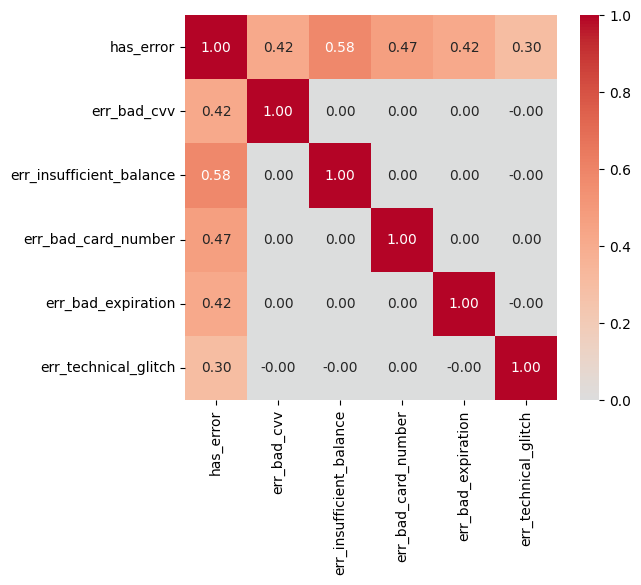

In [22]:
corr = df[ERR_COLS].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

In [23]:
results = []

for col in ERR_COLS:

    X = sm.add_constant(df[[col]].dropna())
    y = df.loc[X.index, "fraud"]

    model = sm.Logit(y, X).fit(disp=0)

    coef = model.params[col]
    pval = model.pvalues[col]
    or_val = np.exp(coef)

    results.append([col, coef, or_val, pval])

pd.DataFrame(results, columns=["feature","coef","OR","p_value"])

,feature,coef,OR,p_value
0,has_error,0.694852,2.003412,3.781187e-30
1,err_bad_cvv,1.437923,4.211938,1.867769e-46
2,err_insufficient_balance,0.578763,1.783831,8.213862e-08
3,err_bad_card_number,0.322607,1.380722,3.067207e-02
4,err_bad_expiration,0.274788,1.316251,1.078775e-01
5,err_technical_glitch,0.176116,1.192576,4.850040e-01


In [24]:
# 1) 유틸: 모델 학습 + 점수
def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score

def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

# 2) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 3) 시간 피처 add-one 다변량 검증
rows = []
BASELINE_NO_HAS_ERROR = [c for c in BASELINE if c != "has_error"]
ERR_COLS = [c for c in ERR_COLS if c != "has_error"]

for tcol in ERR_COLS:
    feats = BASELINE_NO_HAS_ERROR + [tcol]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    # 추가된 피처의 coef/OR/p-value만 뽑기
    coef = model.params.get(tcol, np.nan)
    pval = model.pvalues.get(tcol, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    # baseline 대비 lift 개선량
    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_time_feature": tcol,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": delta_rate,
        "delta_lift_vs_baseline": delta_lift,
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values("delta_lift_vs_baseline", ascending=False)
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.012680807782789972, 'top_decile_rate': 0.04941866107649605, 'top_decile_lift': 3.8971224801282482, 'thr': 0.023932375490811033, 'top_n': 51519}


,added_time_feature,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,err_bad_card_number,0.327060,1.386885,3.114966e-02,0.012681,0.049360,3.892530,-0.000058,-0.004592,51519
1,err_insufficient_balance,0.385819,1.470818,3.791892e-04,0.012681,0.049302,3.887938,-0.000116,-0.009184,51519
2,err_bad_expiration,0.304439,1.355865,7.781858e-02,0.012681,0.049244,3.883346,-0.000175,-0.013776,51519
3,err_technical_glitch,0.091491,1.095807,7.271790e-01,0.012681,0.049244,3.883346,-0.000175,-0.013776,51519
4,err_bad_cvv,1.414980,4.116404,3.795024e-43,0.012681,0.049186,3.878754,-0.000233,-0.018368,51519


**Error History**

In [25]:
def interaction_report(df, x, y, label="fraud", baseline_col=0, min_count=50):
    # (A) rate / count
    rate = df.pivot_table(index=x, columns=y, values=label, aggfunc="mean", observed=False)
    cnt  = df.pivot_table(index=x, columns=y, values=label, aggfunc="size", observed=False).fillna(0).astype(int)

    print(f"\n=== Interaction: {x} x {y} ===")
    print("Fraud rate:")
    display(rate.round(6))
    print("Count:")
    display(cnt)

    # (B) uplift (row-wise)
    if baseline_col in rate.columns:
        base = rate[baseline_col].replace(0, np.nan)
        uplift = rate.div(base, axis=0).round(2) 
        print(f"Uplift vs {y}={baseline_col} within each {x}:")
        display(uplift)

    # (C) Heatmap (optionally mask low-count cells)
    masked = rate.copy()
    masked[cnt < min_count] = np.nan  # 표본 너무 적은 칸은 해석 금지

    plt.figure(figsize=(6, 3.8))
    im = plt.imshow(masked.values, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(masked.columns)), [str(c) for c in masked.columns])
    plt.yticks(range(len(masked.index)), [str(i) for i in masked.index])
    plt.xlabel(y)
    plt.ylabel(x)
    plt.title(f"Fraud rate heatmap: {x} x {y}")

    for i in range(masked.shape[0]):
        for j in range(masked.shape[1]):
            v = masked.values[i, j]
            if pd.notna(v):
                plt.text(j, i, f"{v:.4f}", ha="center", va="center")
            else:
                # low count 등으로 마스킹된 칸 표시
                if cnt.values[i, j] < min_count:
                    plt.text(j, i, f"n<{min_count}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


In [26]:
g = df.groupby("client_id")["has_error"]
df["client_error_last1"] = g.shift(1).fillna(0).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
df["client_error_last3"] = (e1 + e2 + e3).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
e4 = g.shift(4).fillna(0).astype("int8")
e5 = g.shift(5).fillna(0).astype("int8")
df["client_error_last5"] = (e1 + e2 + e3 + e4 + e5).astype("int8")

In [27]:
g = df.groupby("card_id")["has_error"]
df["card_error_last1"] = g.shift(1).fillna(0).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
df["card_error_last3"] = (e1 + e2 + e3).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
e4 = g.shift(4).fillna(0).astype("int8")
e5 = g.shift(5).fillna(0).astype("int8")
df["card_error_last5"] = (e1 + e2 + e3 + e4 + e5).astype("int8")

,feature,k,tx_cnt,fraud_cnt,fraud_rate,lift
0,client_error_last1,0,503436,6295,0.012504,0.986063
1,client_error_last1,1,11752,238,0.020252,1.597049
2,client_error_last3,0,480910,5876,0.012219,0.963543
3,client_error_last3,1,33395,632,0.018925,1.492412
4,client_error_last3,2,876,25,0.028539,2.250552
5,client_error_last3,3,7,0,0.000000,0.000000
6,client_error_last5,0,459492,5522,0.012018,0.947701
7,client_error_last5,1,53004,946,0.017848,1.407458
8,client_error_last5,2,2638,61,0.023124,1.823510
9,client_error_last5,3,49,4,0.081633,6.437496


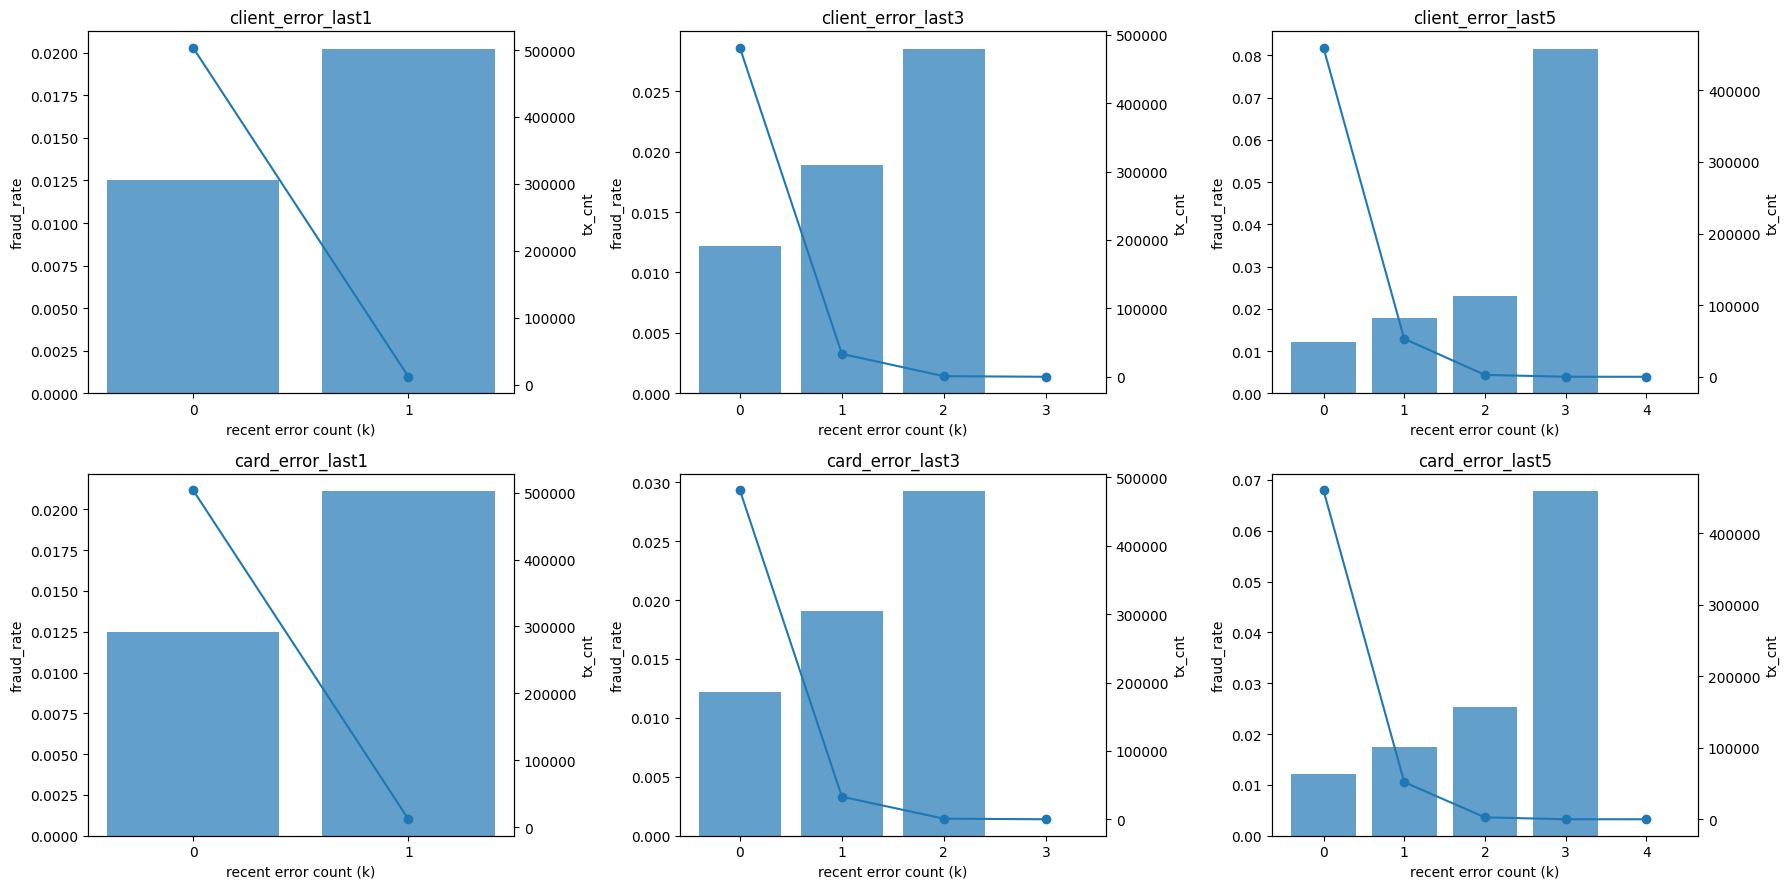


 client_error_last1


,feature,client_error_last1,tx_cnt,fraud_cnt,fraud_rate,lift
0,client_error_last1,0,503436,6295,0.012504,0.986063
1,client_error_last1,1,11752,238,0.020252,1.597049



 client_error_last3


,feature,client_error_last3,tx_cnt,fraud_cnt,fraud_rate,lift
0,client_error_last3,0,480910,5876,0.012219,0.963543
1,client_error_last3,1,33395,632,0.018925,1.492412
2,client_error_last3,2,876,25,0.028539,2.250552
3,client_error_last3,3,7,0,0.000000,0.000000



 client_error_last5


...

,feature,card_error_last1,tx_cnt,fraud_cnt,fraud_rate,lift
0,card_error_last1,0,503491,6286,0.012485,0.984545
1,card_error_last1,1,11697,247,0.021117,1.665235



 card_error_last3


,feature,card_error_last3,tx_cnt,fraud_cnt,fraud_rate,lift
0,card_error_last3,0,481285,5877,0.012211,0.962956
1,card_error_last3,1,33005,630,0.019088,1.505268
2,card_error_last3,2,889,26,0.029246,2.306347
3,card_error_last3,3,9,0,0.000000,0.000000



 card_error_last5


,feature,card_error_last5,tx_cnt,fraud_cnt,fraud_rate,lift
0,card_error_last5,0,460482,5551,0.012055,0.950630
1,card_error_last5,1,51955,910,0.017515,1.381234
2,card_error_last5,2,2685,68,0.025326,1.997182
3,card_error_last5,3,59,4,0.067797,5.346395
4,card_error_last5,4,7,0,0.000000,0.000000


In [28]:
COLS = [
    "client_error_last1", "client_error_last3", "client_error_last5",
    "card_error_last1",   "card_error_last3",   "card_error_last5",
]
LABEL = "fraud"

base_rate = float(df[LABEL].mean())

def make_summary(df, col, label=LABEL, base_rate=base_rate):
    t = (
        df.groupby(col)[label]
          .agg(tx_cnt="count", fraud_cnt="sum", fraud_rate="mean")
          .reset_index()
          .rename(columns={col: "k"})
          .sort_values("k")
    )
    t["lift"] = t["fraud_rate"] / base_rate if base_rate > 0 else np.nan
    t.insert(0, "feature", col)
    return t

summaries = {c: make_summary(df, c) for c in COLS}
summary_df = pd.concat(summaries.values(), ignore_index=True)

display(summary_df)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=False)
axes = axes.ravel()

for ax, col in zip(axes, COLS):
    t = summaries[col]


    ax.bar(t["k"], t["fraud_rate"], alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel("recent error count (k)")
    ax.set_ylabel("fraud_rate")


    ax2 = ax.twinx()
    ax2.plot(t["k"], t["tx_cnt"], marker="o")
    ax2.set_ylabel("tx_cnt")


    ax.set_xticks(t["k"].tolist())

plt.tight_layout()
plt.show()


for col in COLS:
    print("\n", col)
    display(summaries[col].rename(columns={"k": col}))

| CVV        | Error History |
| ---------- | ------------- |
| 순간 이벤트     | 누적 위험         |
| OR≈4 단일 거래 | k 증가 시 점진적 증가 |
| hazard 아님  | 명확한 hazard 구조 |


Error history는:

공격 시도 누적에 따른 위험 상승 패턴이 명확히 존재

| Window | 설명            |
| ------ | ------------- |
| last1  | 즉각적 위험        |
| last3  | 가장 안정적인 누적 신호 |
| last5  | 더 강하지만 분산 큼   |


In [29]:
results = []

for col in COLS:

    X = sm.add_constant(df[[col]].dropna())
    y = df.loc[X.index, "fraud"]

    model = sm.Logit(y, X).fit(disp=0)

    coef = model.params[col]
    pval = model.pvalues[col]
    or_val = np.exp(coef)

    results.append([col, coef, or_val, pval])

pd.DataFrame(results, columns=["feature","coef","OR","p_value"])

,feature,coef,OR,p_value
0,client_error_last1,0.490070,1.632430,2.027779e-13
1,client_error_last3,0.441254,1.554656,2.221879e-29
2,client_error_last5,0.390652,1.477945,3.867427e-36
3,card_error_last1,0.534321,1.706289,3.604904e-16
4,card_error_last3,0.450645,1.569323,1.159101e-30
5,card_error_last5,0.382588,1.466074,2.199395e-34


In [31]:
LABEL = "fraud"

# 1) 유틸: 모델 학습 + 점수
def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score

def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

# 2) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE_NO_HAS_ERROR, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 3) 시간 피처 add-one 다변량 검증
rows = []

for tcol in COLS:
    feats = BASELINE_NO_HAS_ERROR + [tcol]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    # 추가된 피처의 coef/OR/p-value만 뽑기
    coef = model.params.get(tcol, np.nan)
    pval = model.pvalues.get(tcol, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    # baseline 대비 lift 개선량
    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_time_feature": tcol,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": delta_rate,
        "delta_lift_vs_baseline": delta_lift,
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values("delta_lift_vs_baseline", ascending=False)
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.012680807782789972, 'top_decile_rate': 0.049282788874007645, 'top_decile_lift': 3.886407689334494, 'thr': 0.023770607332776663, 'top_n': 51519}


,added_time_feature,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,client_error_last3,0.398149,1.489066,9.176030e-24,0.012681,0.049516,3.904776,0.000233,0.018368,51519
1,card_error_last3,0.408000,1.503807,8.659196e-25,0.012681,0.049438,3.898653,0.000155,0.012245,51519
2,card_error_last5,0.347197,1.415096,5.683486e-28,0.012681,0.049399,3.895592,0.000116,0.009184,51519
3,card_error_last1,0.497164,1.644052,6.658559e-14,0.012681,0.049360,3.892530,0.000078,0.006123,51519
4,client_error_last5,0.345742,1.413038,4.287262e-28,0.012681,0.049283,3.886408,0.000000,0.000000,51519
5,client_error_last1,0.439451,1.551854,7.515385e-11,0.012681,0.049089,3.871101,-0.000194,-0.015307,51519


client_error_last3가 가장 개선폭 큼

card_error_last3가 그 다음

last5는 추가 이득 거의 없음

client_error_last1은 오히려 악화

1. last1이 OR는 가장 높은데 왜 top-decile 개선은 약함 -> OR가 높다고 ranking power가 높은 것은 아니다.
2. client vs card -> decile 개선폭은 client_error_last3 > card_error_last3 → 고객 단위 누적이 약간 더 설명력 있음.

누적 3회 window가 가장 균형적

=> client_error_last3


In [49]:
base = df_pre['fraud'].mean()

client_rate = df_pre.loc[df_pre['client_error_last3'] >= 1, 'fraud'].mean()
card_rate   = df_pre.loc[df_pre['card_error_last3'] >= 1,   'fraud'].mean()

client_delta = (client_rate / base) if base > 0 else np.nan
card_delta   = (card_rate / base) if base > 0 else np.nan

print(f"client_error_last3 lift: {client_delta:.6f}")
print(f"card_error_last3 lift:   {card_delta:.6f}")
print(f"차이: {client_delta - card_delta:.6f}")

client_error_last3 lift: 1.511482
card_error_last3 lift:   1.525874
차이: -0.014392


> ERR history는 card vs client 구분이 큰 차이를 만들지 않는다.

In [32]:

KEEP_COL = "client_error_last3"

drop_cols = [c for c in COLS if c != KEEP_COL]

df = df.drop(columns=drop_cols)

print("Dropped columns:", drop_cols)
print("Remaining columns from COLS:", [c for c in COLS if c in df.columns])

Dropped columns: ['client_error_last1', 'client_error_last5', 'card_error_last1', 'card_error_last3', 'card_error_last5']
Remaining columns from COLS: ['client_error_last3']



### Keep Columns

| column             | 역할            | 근거                                                  |
| ------------------ | ------------- | --------------------------------------------------- |
| err_bad_cvv        | 순간 이벤트형 신호    | fraud 이전 필터 기준에서도 명확한 hazard 상승. 온라인 환경에서 직접적 공격 신호 |
| has_error          | 광범위 오류 발생 플래그 | 세부 에러 외 추가 오류 가능성 존재. 약하지만 안정적 베이스 신호               |
| card_error_last3   | 카드 단위 누적 위험   | top-decile lift 1.526. 카드 공격 반복 패턴 반영               |
| client_error_last3 | 고객 단위 누적 위험   | top-decile lift 1.511. 계정 단위 이상 행태 반영               |
| error_count        | 동시 발생 강도 신호   | 0→1→2 단조 증가. rare high-risk trigger로 보조적 가치         |

---

### Drop Columns

| column                   | 사유                  | 비고                  |
| ------------------------ | ------------------- | ------------------- |
| err_bad_card_number      | CVV 대비 구분력 약함       | 이벤트성 신호는 CVV가 대표    |
| err_bad_expiration       | lift 미미             | 추가 정보량 제한적          |
| err_insufficient_balance | 사기 직접 신호 아님         | 정상 사용자 행태 가능성 높음    |
| err_technical_glitch     | 시스템 품질 지표 성격        | 사기 위험과 직접 연관성 낮음    |
| card_error_last1         | last3 대비 정보량 낮음     | 누적 구조가 더 안정적        |
| client_error_last1       | last3 대비 정보량 낮음     | 단기 노이즈 가능성          |
| *_last5                  | last3 대비 추가 설명력 제한적 | 과도한 누적은 noise 증가 가능 |

---

### 최종 ERR Feature Set

| category             | columns            |
| -------------------- | ------------------ |
| Event Signal         | err_bad_cvv        |
| Broad Error Flag     | has_error          |
| Card-level History   | card_error_last3   |
| Client-level History | client_error_last3 |
| Intensity            | error_count        |

---

In [51]:
df.columns

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'merchant_id', 'mcc',
       'fraud', 'has_error', 'err_bad_card_number', 'err_bad_expiration',
       'err_bad_cvv', 'err_insufficient_balance', 'err_technical_glitch',
       'weekday', 'is_refund', 'log_abs_amount', 'current_age',
       'per_capita_income', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards', 'has_chip', 'num_cards_issued', 'credit_limit',
       'year_pin_last_changed', 'expires_year', 'expires_month',
       'months_to_expire', 'is_credit', 'is_prepaid', 'male', 'cb_Visa',
       'cb_Mastercard', 'cb_Amex', 'cb_Discover', 'months_from_account',
       'years_since_pin_change', 'years_to_retirement', 'income_ratio_region',
       'log_yearly_income', 'log_income_ratio_region', 'abs_amount',
       'amount_income_ratio', 'amount_limit_ratio', 'log_amount_income_ratio',
       'log_amount_limit_ratio', 'month_sin', 'is_risky_month',
       'is_risky_wd_hour', 'is_risky_hour', 'hour_sin', 'ho

In [52]:
df.drop(columns=["card_fraud_cum","card_fraud_cum_prev", "err_bad_card_number", "err_bad_expiration", "err_insufficient_balance", "err_technical_glitch"], inplace=True)

In [54]:
df.columns

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'merchant_id', 'mcc',
       'fraud', 'has_error', 'err_bad_cvv', 'weekday', 'is_refund',
       'log_abs_amount', 'current_age', 'per_capita_income', 'yearly_income',
       'total_debt', 'credit_score', 'num_credit_cards', 'has_chip',
       'num_cards_issued', 'credit_limit', 'year_pin_last_changed',
       'expires_year', 'expires_month', 'months_to_expire', 'is_credit',
       'is_prepaid', 'male', 'cb_Visa', 'cb_Mastercard', 'cb_Amex',
       'cb_Discover', 'months_from_account', 'years_since_pin_change',
       'years_to_retirement', 'income_ratio_region', 'log_yearly_income',
       'log_income_ratio_region', 'abs_amount', 'amount_income_ratio',
       'amount_limit_ratio', 'log_amount_income_ratio',
       'log_amount_limit_ratio', 'month_sin', 'is_risky_month',
       'is_risky_wd_hour', 'is_risky_hour', 'hour_sin', 'hour_cos',
       'client_error_last3', 'error_count', 'card_error_last3'],
      dtype='object')

In [55]:
df.to_parquet("data")

---

# EDA — Error Feature 분석 요약

## 1. 분석 목적

Error 관련 피처(`has_error`, `err_*`)가 사기(fraud) 탐지에 독립적인 예측력을 갖는지 검증하고, 최종 모델에 포함할 피처 셋을 확정한다.

---

## 2. 기초 분포 확인

`has_error`는 세부 에러(`err_bad_cvv`, `err_bad_card_number`, `err_bad_expiration`, `err_insufficient_balance`, `err_technical_glitch`)의 **논리합(OR)**으로 완벽하게 설명된다 — mismatch 0건 확인.

> → `has_error`는 세부 에러의 포괄 플래그이므로 다중공선성 주의가 필요하나, 세부 에러가 없는 경우에도 역할을 할 수 있어 병존 가능.

---

## 3. 세부 에러별 Fraud Lift

| Feature | Fraud Rate (=1) | Lift | Support Rate |
|---|---|---|---|
| err_bad_cvv | 0.0507 | **4.00** | 0.40% |
| has_error | 0.0245 | 1.94 | 2.29% |
| err_insufficient_balance | 0.0223 | 1.76 | 0.78% |
| err_bad_card_number | 0.0174 | 1.37 | 0.51% |
| err_bad_expiration | 0.0166 | 1.31 | 0.41% |
| err_technical_glitch | 0.0151 | 1.19 | 0.21% |

**핵심 관찰:**

- `err_bad_cvv`는 Lift ≈ 4로 압도적이나, support가 0.4%로 낮아 과적합/불안정 가능성을 Wilson CI로 검증했고 **CI 전체가 base rate 위에 위치** → 신호로 신뢰할 수 있음.
- `err_technical_glitch`는 Lift 1.19로, 사기 위험 신호라기보다 **시스템 품질 지표** 성격에 가깝다.

---

## 4. err_bad_cvv 심층 분석

### 4-1. 구조적 특수성

Mann-Whitney 검정 결과, CVV 에러 집단은 금액·소득·시간대 등 다른 연속형 피처에서 Cohen's d ≥ 0.10인 변수가 **없음** — 즉 CVV 오류는 다른 피처들의 대리변수가 아니라 **그 자체로 독립적인 위험 신호**다.

이진 피처 분석에서도 `has_error`를 제외하면 의미 있는 연관 피처 없음 (p > 0.05).

> CVV 오류는 정상 소비 행동의 분포 밖에 있는 행위 자체가 위험 신호이며, 다른 피처를 통해 매개되지 않는다.

### 4-2. 카드 단위 사전 누적 분석

CVV error 발생 이전(`card_fraud_cum_prev == 0`) 데이터로 카드별 CVV 누적 횟수 vs fraud 발생률을 분석한 결과:

| CVV error 누적 수 | fraud 카드 비율 | lift |
|---|---|---|
| 0 | 81.9% | (기준) |
| 1 | 12.2% | — |
| 2 | 3.2% | — |

- CVV error를 0번 겪은 카드의 fraud 발생률이 가장 높음.
- 에러 횟수가 늘어도 fraud 확률이 높아지지 않음.

> → `err_bad_cvv`는 **"사건 직전 이벤트형 신호"**이지, 반복 공격 시도의 전조 누적 신호가 아니다.  
> → **거래 단위 real-time 모델에 매우 적합, 카드 단위 누적 히스토리 피처로는 부적합.**

---

## 5. Error 세부 피처의 다변량 기여도 (Baseline 대비 top-decile lift)

Baseline에 각 에러 피처를 하나씩 추가한 로지스틱 회귀 결과:

| Added Feature | delta_lift |
|---|---|
| err_bad_card_number | -0.0046 |
| err_insufficient_balance | -0.0092 |
| err_bad_expiration | -0.0138 |
| err_technical_glitch | -0.0138 |
| **err_bad_cvv** | **-0.0184** |

모든 에러 피처가 Baseline top-decile lift를 소폭 감소시킨다. 이는 이들 피처가 Baseline 내 `has_error`와 중복 정보를 가지고 있기 때문이며, **세부 에러 피처들은 `has_error`로 이미 상당 부분 대체 가능**하다는 것을 시사한다.

> → 세부 에러 중 단독 추가 가치가 있는 건 `err_bad_cvv` 뿐이며, 나머지는 `has_error`에 흡수된다.

---

## 6. Error History 피처 분석

직전 1/3/5회 거래의 error 발생 횟수를 카드(`card_*`) 및 고객(`client_*`) 단위로 생성해 분석.

### 6-1. Fraud Lift by Window

| Feature | k=1 lift | k=2 lift | k=3 lift |
|---|---|---|---|
| client_error_last1 | 1.60 | — | — |
| client_error_last3 | 1.49 | 2.25 | — |
| client_error_last5 | 1.41 | 1.82 | **6.44** |
| card_error_last1 | 1.67 | — | — |
| card_error_last3 | 1.51 | 2.31 | — |
| card_error_last5 | 1.38 | 2.00 | **5.35** |

에러 횟수 k가 늘어날수록 fraud rate가 단조 증가하는 **명확한 hazard 구조** 확인.

### 6-2. Baseline 대비 top-decile lift 개선 (add-one 다변량)

| Added Feature | delta_lift |
|---|---|
| **client_error_last3** | **+0.018** |
| card_error_last3 | +0.012 |
| card_error_last5 | +0.009 |
| card_error_last1 | +0.006 |
| client_error_last5 | +0.000 |
| client_error_last1 | -0.015 |

- `client_error_last3`이 Baseline 대비 lift 개선폭이 가장 크다.
- `last5`는 추가 이득이 미미하며, `last1`은 단기 노이즈로 인해 오히려 악화.
- OR이 높다고 ranking power가 높은 것은 아님(`card_error_last1` vs 개선폭).

> → **`client_error_last3`을 대표 Error History 피처로 선정.** card vs client는 큰 차이를 만들지 않지만 고객 단위가 약간 더 설명력이 높음.

---

## 7. CVV vs Error History 비교

| 구분 | err_bad_cvv | Error History |
|---|---|---|
| 신호 성격 | 순간 이벤트 | 누적 위험 |
| 단일 거래 OR | ≈ 4.2 | 1.5~1.7 |
| hazard 구조 | 없음 | 명확히 존재 |
| 누적 반복 공격 전조 | 아님 | 해당 |
| 적합 사용처 | Real-time 단일 거래 점수 | History 기반 위험 누적 |

---

## 8. 최종 피처 결정

### ✅ KEEP

| Feature | 역할 | 근거 |
|---|---|---|
| `err_bad_cvv` | 순간 이벤트형 신호 | Lift ≈ 4, Wilson CI 전체 base rate 이상, 독립 신호 |
| `has_error` | 광범위 오류 플래그 | 세부 에러의 대표 요약, 안정적 베이스 신호 |
| `client_error_last3` | 고객 단위 누적 위험 | top-decile lift 개선 최대, hazard 구조 명확 |
| `card_error_last3` | 카드 단위 누적 위험 | client 다음으로 개선폭 크고 카드 단위 공격 반복 반영 |
| `error_count` | 동시 발생 강도 신호 | 0→1→2 단조 증가, rare high-risk trigger로 보조 가치 |

### ❌ DROP

| Feature | 사유 |
|---|---|
| `err_bad_card_number` | CVV 대비 구분력 약함. 이벤트성 신호는 CVV가 대표 |
| `err_bad_expiration` | Lift 1.31로 미미. 다변량에서 추가 정보량 제한적 |
| `err_insufficient_balance` | 사기 직접 신호라기보다 잔액 부족 — 정상 사용자 행태 가능성 |
| `err_technical_glitch` | 시스템 품질 지표 성격. 사기 위험과 직접 연관성 낮음 |
| `card_error_last1` | last3 대비 ranking power 낮음. 단기 노이즈 가능성 |
| `client_error_last1` | 다변량 검증에서 오히려 lift 악화 |
| `client_error_last5` / `card_error_last5` | last3 대비 추가 설명력 거의 없음. 과도한 누적은 noise 증가 |
| `card_fraud_cum`, `card_fraud_cum_prev` | 분석용 중간 변수. 미래 정보 누출 위험 |

---

## 9. 최종 Error Feature Set 요약

| Category | Feature |
|---|---|
| Event Signal | `err_bad_cvv` |
| Broad Error Flag | `has_error` |
| Client-level History | `client_error_last3` |
| Card-level History | `card_error_last3` |
| Intensity | `error_count` |